# Phase 2: Non-Linear Modeling, Autoregressive Features, and Gradient Boosting

**Objective:** Build on the Phase 1 baseline by training more flexible machine-learning models on the same time-aware feature pipeline. This updated notebook adds:
- `lag_pop_change_1`
- `lag_pop_change_2`
- `income_growth`
- a **HistGradientBoosting model** in addition to Random Forest

The goal is to test whether autoregressive signals and boosting-based nonlinear modeling can improve held-out predictive performance.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from pathlib import Path
from math import radians, cos, sin, asin, sqrt

from sklearn.preprocessing import StandardScaler, PowerTransformer, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import GridSearchCV
from sklearn.inspection import permutation_importance


## 1. Data Ingestion & Spatial Initialization
We begin by loading the consolidated historical profile for Puerto Rico (2010-2024). 

Because disaster impacts are highly localized, we map each of the 78 municipalities to its exact geographic centroid (Latitude/Longitude). This spatial initialization is crucial for the vectorized distance functions that calculate how close the eye of a hurricane or the epicenter of an earthquake was to a specific town.

In [2]:
# 1. Load Data
df = pd.read_csv('../data/puerto_rico_master_profile.csv')
df['municipio'] = df['municipio'].str.replace(' Municipio', '', case=False).str.strip()
df = df.sort_values(by=['municipio', 'year']).reset_index(drop=True)

# 2. Add Coordinates
municipio_coords = {'Adjuntas': (18.1627, -66.7222), 'Aguada': (18.3605, -67.1882), 'Aguadilla': (18.4275, -67.1541), 'Aguas Buenas': (18.2572, -66.1031), 'Aibonito': (18.1408, -66.2663), 'Añasco': (18.2827, -67.1399), 'Arecibo': (18.4724, -66.7157), 'Arroyo': (17.9658, -66.0614), 'Barceloneta': (18.4505, -66.5385), 'Barranquitas': (18.1861, -66.3061), 'Bayamón': (18.3808, -66.1557), 'Cabo Rojo': (18.0866, -67.1457), 'Caguas': (18.2325, -66.0391), 'Camuy': (18.4838, -66.8450), 'Canóvanas': (18.3791, -65.9011), 'Carolina': (18.3808, -65.9574), 'Cataño': (18.4388, -66.1182), 'Cayey': (18.1119, -66.1663), 'Ceiba': (18.2633, -65.6474), 'Ciales': (18.3361, -66.4688), 'Cidra': (18.1758, -66.1617), 'Coamo': (18.0855, -66.3579), 'Comerío': (18.2183, -66.2257), 'Corozal': (18.3411, -66.3161), 'Culebra': (18.3030, -65.3010), 'Dorado': (18.4588, -66.2677), 'Fajardo': (18.3258, -65.6524), 'Florida': (18.3625, -66.5614), 'Guánica': (17.9716, -66.9080), 'Guayama': (17.9741, -66.1100), 'Guayanilla': (18.0130, -66.7919), 'Guaynabo': (18.3580, -66.1111), 'Gurabo': (18.2544, -65.9728), 'Hatillo': (18.4863, -66.8250), 'Hormigueros': (18.1397, -67.1274), 'Humacao': (18.1497, -65.8274), 'Isabela': (18.5011, -67.0247), 'Jayuya': (18.2186, -66.5916), 'Juana Díaz': (18.0525, -66.5064), 'Juncos': (18.2275, -65.9211), 'Lajas': (18.0497, -67.0594), 'Lares': (18.2947, -66.8771), 'Las Marías': (18.2514, -66.9922), 'Las Piedras': (18.1827, -65.8661), 'Loíza': (18.4330, -65.8797), 'Luquillo': (18.3725, -65.7166), 'Manatí': (18.4274, -66.4922), 'Maricao': (18.1808, -66.9799), 'Maunabo': (18.0072, -65.8994), 'Mayagüez': (18.2011, -67.1397), 'Moca': (18.3947, -67.1131), 'Morovis': (18.3258, -66.4053), 'Naguabo': (18.2119, -65.7350), 'Naranjito': (18.3008, -66.2447), 'Orocovis': (18.2269, -66.4411), 'Patillas': (18.0066, -66.0161), 'Peñuelas': (18.0622, -66.7219), 'Ponce': (18.0111, -66.6141), 'Quebradillas': (18.4738, -66.9385), 'Rincón': (18.3403, -67.2500), 'Río Grande': (18.3794, -65.8311), 'Sabana Grande': (18.0777, -66.9605), 'Salinas': (17.9775, -66.2974), 'San Germán': (18.0816, -67.0400), 'San Juan': (18.4655, -66.1057), 'San Lorenzo': (18.1894, -65.9611), 'San Sebastián': (18.3372, -66.9905), 'Santa Isabel': (17.9666, -66.4050), 'Toa Alta': (18.3883, -66.2485), 'Toa Baja': (18.4438, -66.2591), 'Trujillo Alto': (18.3547, -66.0072), 'Utuado': (18.2655, -66.7005), 'Vega Alta': (18.4119, -66.3314), 'Vega Baja': (18.4438, -66.3874), 'Vieques': (18.1261, -65.4400), 'Villalba': (18.1275, -66.4925), 'Yabucoa': (18.0505, -65.8794), 'Yauco': (18.0350, -66.8499)}
df['lat'] = df['municipio'].map(lambda x: municipio_coords.get(x, (None, None))[0])
df['lon'] = df['municipio'].map(lambda x: municipio_coords.get(x, (None, None))[1])

# 3. Process Shocks
hurricane_tracks = pd.read_csv('../data/natural_disasters/caribbean_hurricane_tracks_2010_2025.csv')
with open('../data/natural_disasters/puerto_rico_earthquakes.json') as f:
    eq_data = pd.DataFrame(json.load(f))
eq_data['year'] = pd.to_datetime(eq_data['date']).dt.year

def get_distances_vectorized(target_lat, target_lon, lats, lons):
    target_lat, target_lon = np.radians(target_lat), np.radians(target_lon)
    lats, lons = np.radians(lats), np.radians(lons)
    return 2 * np.arcsin(np.sqrt(np.sin((lats - target_lat)/2)**2 + np.cos(target_lat) * np.cos(lats) * np.sin((lons - target_lon)/2)**2)) * 6371

def get_shocks(row):
    if pd.isna(row['lat']): return 0, 0
    # Hurricane
    h_year = hurricane_tracks[hurricane_tracks['Year'] == row['year']]
    h_max = h_year.iloc[get_distances_vectorized(row['lat'], row['lon'], h_year['Lat'].values, h_year['Lon'].values) <= 100]['Wind_Knots'].max() if not h_year.empty else 0
    # Seismic
    s_year = eq_data[(eq_data['year'] == row['year']) & (eq_data['mag'] >= 4.0)]
    s_max = s_year.iloc[get_distances_vectorized(row['lat'], row['lon'], s_year['latitude'].values, s_year['longitude'].values) <= 50]['mag'].max() if not s_year.empty else 0
    return h_max if not pd.isna(h_max) else 0, s_max if not pd.isna(s_max) else 0

df[['max_wind_knots', 'max_seismic_mag']] = df.apply(lambda r: pd.Series(get_shocks(r)), axis=1)

## Phase 2 methodological upgrades

This notebook has been cleaned up so that **one canonical preprocessing and modeling pipeline** drives all downstream results.

Key fixes in this revision:
1. Removed the duplicate early feature-pipeline path.
2. Recomputed the **linear baseline inside this notebook** on the same train/test split.
3. Replaced row-based time-series CV with **year-block expanding-window validation**.
4. Added **naive forecasting benchmarks** for context.
5. Hardened the SVI/PCA pipeline against infinities and extreme outliers.
6. Removed the duplicate broken permutation-importance block.
7. Rewrote the conclusions so they match the held-out metrics more cautiously.

## 2. Consolidated, non-leaked feature engineering pipeline

This section is now the **single source of truth** for data preparation. It builds:

- the train-only **SVI-15 vulnerability index**
- lagged crime features
- lagged population-change features
- income growth
- SVI × shock interactions
- a consistent train/test split used by **all** models and benchmarks

The final feature list is stored once as `FINAL_FEATURES`, and the simpler
reduced-feature linear benchmark is stored once as `BASELINE_FEATURES`.

### Preprocessing note

Disaster variables are often zero-inflated and right-skewed, so the notebook
still applies a **Yeo–Johnson power transformation** to shock variables, fit on
training data only and then transferred to the held-out test set.

For the SVI block, this revision also:
- replaces infinities before modeling,
- clips extreme values using train-only quantile caps, and
- reports diagnostics before PCA so warnings are easier to interpret.

In [3]:
# --- STEP 1: INTEGRATE CRIME SHOCKS ---
def load_crime_data_fixed(file_path):
    xl = pd.ExcelFile(file_path)
    all_years = []
    for sheet_name in xl.sheet_names:
        if not sheet_name.isdigit():
            continue
        df_year = xl.parse(sheet_name)
        df_year.columns = [str(c).strip().lower() for c in df_year.columns]

        mun_cols = [c for c in df_year.columns if 'mun' in c]
        if mun_cols:
            df_year = df_year.rename(columns={mun_cols[0]: 'municipio'})

        df_year = df_year.loc[:, ~df_year.columns.duplicated()]
        df_year = df_year.rename(columns={'total ': 'total'})

        numeric_cols = ['murder', 'robbery', 'burglary', 'larceny / theft', 'total']
        for col in numeric_cols:
            if col in df_year.columns:
                df_year[col] = (
                    df_year[col]
                    .astype(str)
                    .str.replace('.', '', regex=False)
                    .str.replace(',', '', regex=False)
                )
                df_year[col] = pd.to_numeric(df_year[col], errors='coerce').fillna(0).astype(int)

        df_year['year'] = int(sheet_name)
        keep_cols = ['municipio', 'year'] + [c for c in numeric_cols if c in df_year.columns]
        all_years.append(df_year[keep_cols])

    return pd.concat(all_years, ignore_index=True)

crime_path = '../data/crime/PR_Crime_Summary_2010_2025.xlsx'
crime_df = load_crime_data_fixed(crime_path)

df['mun_key'] = df['municipio'].astype(str).str.upper().str.strip().str.replace(' MUNICIPIO', '', regex=False)
crime_df['mun_key'] = crime_df['municipio'].astype(str).str.upper().str.strip()

df = df.merge(crime_df.drop(columns=['municipio']), on=['mun_key', 'year'], how='left')
df = df.fillna(0)
df = df.drop(columns=['mun_key'])

# --- STEP 2: CORE RATES, TARGET, AND LAGS ---
df['murder_rate'] = (df['murder'] / df['total_population']) * 1000
df['robbery_rate'] = (df['robbery'] / df['total_population']) * 1000
df['burglary_rate'] = (df['burglary'] / df['total_population']) * 1000

df = df.sort_values(['municipio', 'year']).copy()
df['year'] = pd.to_numeric(df['year'], errors='coerce')
df['target_pop_change'] = df.groupby('municipio')['total_population'].pct_change() * 100

df['lag_violent_crime_rate'] = (
    df.groupby('municipio')['murder_rate'].shift(1) +
    df.groupby('municipio')['robbery_rate'].shift(1)
)
df['lag_property_crime_rate'] = df.groupby('municipio')['burglary_rate'].shift(1)

df['lag_pop_change_1'] = df.groupby('municipio')['target_pop_change'].shift(1)
df['lag_pop_change_2'] = df.groupby('municipio')['target_pop_change'].shift(2)
df['income_growth'] = df.groupby('municipio')['median_income_real'].pct_change() * 100

# --- STEP 3: SVI INPUTS ---
svi_cols = [
    'poverty_rate_pct',
    'unemployment_rate_pct',
    'per_capita_income',
    'no_hs_diploma_pct',
    'under_18_pct',
    'over_65_pct',
    'disability_pct',
    'single_parent_pct',
    'minority_pct',
    'limited_english_pct',
    'multi_unit_housing_pct',
    'mobile_homes_pct',
    'crowding_pct',
    'no_vehicle_pct',
    'pct_group_quarters'
]

for col in svi_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df['per_capita_income_inv'] = -df['per_capita_income']

SVI_PCA_COLS = [
    'poverty_rate_pct',
    'unemployment_rate_pct',
    'per_capita_income_inv',
    'no_hs_diploma_pct',
    'under_18_pct',
    'over_65_pct',
    'disability_pct',
    'single_parent_pct',
    'minority_pct',
    'limited_english_pct',
    'multi_unit_housing_pct',
    'mobile_homes_pct',
    'crowding_pct',
    'no_vehicle_pct',
    'pct_group_quarters'
]

BASE_NUMERIC_COLS = [
    'median_income_real',
    'max_wind_knots',
    'max_seismic_mag',
    'lag_pop_change_1',
    'lag_pop_change_2',
    'income_growth',
    'lag_violent_crime_rate',
    'lag_property_crime_rate',
    'lat',
    'lon'
]

for col in BASE_NUMERIC_COLS:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

df = df.replace([np.inf, -np.inf], np.nan)

MODEL_REQUIRED_COLS = ['municipio', 'year', 'target_pop_change'] + SVI_PCA_COLS + [c for c in BASE_NUMERIC_COLS if c in df.columns]
df_clean = df.dropna(subset=MODEL_REQUIRED_COLS).copy()

# --- STEP 4: CONSISTENT TRAIN/TEST SPLIT ---
TRAIN_END_YEAR = 2020
TEST_START_YEAR = 2021

train_mask = df_clean['year'] <= TRAIN_END_YEAR
test_mask = df_clean['year'] >= TEST_START_YEAR

if not train_mask.any() or not test_mask.any():
    raise ValueError("Time-based split produced an empty train or test set. Check the year range in df_clean.")

df_clean['split'] = np.where(train_mask, 'train', np.where(test_mask, 'test', 'unused'))
df_model = df_clean[df_clean['split'].isin(['train', 'test'])].copy()

train_df = df_model[df_model['split'] == 'train'].copy().reset_index(drop=True)
test_df = df_model[df_model['split'] == 'test'].copy().reset_index(drop=True)

# --- STEP 5: TRAIN-ONLY OUTLIER CAPPING FOR SVI INPUTS ---
svi_clip_bounds = {}
for col in SVI_PCA_COLS:
    lower = train_df[col].quantile(0.01)
    upper = train_df[col].quantile(0.99)
    svi_clip_bounds[col] = (lower, upper)
    train_df[col] = train_df[col].clip(lower=lower, upper=upper)
    test_df[col] = test_df[col].clip(lower=lower, upper=upper)

# --- STEP 6: TRAIN-ONLY PCA FOR VULNERABILITY INDEX ---
scaler_svi = StandardScaler()
pca_svi = PCA(n_components=1, random_state=42)

train_svi_scaled = scaler_svi.fit_transform(train_df[SVI_PCA_COLS])
test_svi_scaled = scaler_svi.transform(test_df[SVI_PCA_COLS])

train_df['vulnerability_index'] = pca_svi.fit_transform(train_svi_scaled).ravel()
test_df['vulnerability_index'] = pca_svi.transform(test_svi_scaled).ravel()

loading_series = pd.Series(pca_svi.components_[0], index=SVI_PCA_COLS)
orientation_cols = [c for c in ['poverty_rate_pct', 'unemployment_rate_pct', 'no_vehicle_pct'] if c in loading_series.index]
if orientation_cols and loading_series[orientation_cols].mean() < 0:
    train_df['vulnerability_index'] = -train_df['vulnerability_index']
    test_df['vulnerability_index'] = -test_df['vulnerability_index']
    loading_series = -loading_series

svi_minmax = MinMaxScaler()
train_df['vulnerability_index'] = svi_minmax.fit_transform(train_df[['vulnerability_index']])
test_df['vulnerability_index'] = svi_minmax.transform(test_df[['vulnerability_index']])

# --- STEP 7: INTERACTIONS AND FINAL FEATURE LISTS ---
train_df['svi_x_wind'] = train_df['vulnerability_index'] * train_df['max_wind_knots']
train_df['svi_x_quake'] = train_df['vulnerability_index'] * train_df['max_seismic_mag']
test_df['svi_x_wind'] = test_df['vulnerability_index'] * test_df['max_wind_knots']
test_df['svi_x_quake'] = test_df['vulnerability_index'] * test_df['max_seismic_mag']

FINAL_FEATURES = [
    'vulnerability_index',
    'median_income_real',
    'max_wind_knots',
    'max_seismic_mag',
    'lag_violent_crime_rate',
    'lag_property_crime_rate',
    'lag_pop_change_1',
    'lag_pop_change_2',
    'income_growth',
    'svi_x_wind',
    'svi_x_quake'
]

BASELINE_FEATURES = [
    'vulnerability_index',
    'median_income_real',
    'max_wind_knots',
    'max_seismic_mag',
    'lag_violent_crime_rate',
    'lag_property_crime_rate'
]

SHOCK_COLS = [c for c in [
    'max_wind_knots',
    'max_seismic_mag'
] if c in FINAL_FEATURES]

# Fit Yeo-Johnson on training data only and transfer to test data.
if SHOCK_COLS:
    power_transformer = PowerTransformer(method='yeo-johnson', standardize=False)
    train_df.loc[:, SHOCK_COLS] = power_transformer.fit_transform(train_df[SHOCK_COLS])
    test_df.loc[:, SHOCK_COLS] = power_transformer.transform(test_df[SHOCK_COLS])

    # Refresh interaction features after transforming the underlying shock variables.
    train_df['svi_x_wind'] = train_df['vulnerability_index'] * train_df['max_wind_knots']
    train_df['svi_x_quake'] = train_df['vulnerability_index'] * train_df['max_seismic_mag']
    test_df['svi_x_wind'] = test_df['vulnerability_index'] * test_df['max_wind_knots']
    test_df['svi_x_quake'] = test_df['vulnerability_index'] * test_df['max_seismic_mag']

# Canonical modeling matrices
X_train = train_df[FINAL_FEATURES].copy()
X_test = test_df[FINAL_FEATURES].copy()
y_train = train_df['target_pop_change'].copy()
y_test = test_df['target_pop_change'].copy()

X_train_baseline = train_df[BASELINE_FEATURES].copy()
X_test_baseline = test_df[BASELINE_FEATURES].copy()

# Year-block expanding-window validation folds
train_years_sorted = sorted(train_df['year'].dropna().unique())
cv_splits = []
for year in train_years_sorted[3:]:
    train_idx = train_df.index[train_df['year'] < year].to_numpy()
    val_idx = train_df.index[train_df['year'] == year].to_numpy()
    if len(train_idx) > 0 and len(val_idx) > 0:
        cv_splits.append((train_idx, val_idx))

if len(cv_splits) < 2:
    raise ValueError("Not enough yearly blocks to create expanding-window CV splits.")

cv_fold_summary = pd.DataFrame([
    {
        'fold': i + 1,
        'train_years': f"{int(train_df.iloc[tr]['year'].min())}-{int(train_df.iloc[tr]['year'].max())}",
        'validation_year': int(train_df.iloc[val]['year'].iloc[0]),
        'train_rows': len(tr),
        'validation_rows': len(val)
    }
    for i, (tr, val) in enumerate(cv_splits)
])

print("--- Phase 2 data preparation complete ---")
print(f"Training years: <= {TRAIN_END_YEAR}")
print(f"Testing years: >= {TEST_START_YEAR}")
print(f"Train rows: {len(train_df)}")
print(f"Test rows: {len(test_df)}")
print(f"Explained variance of PCA component: {pca_svi.explained_variance_ratio_[0]:.4f}")
print("\nFinal Phase 2 features:")
for f in FINAL_FEATURES:
    print(f" - {f}")

print("\nReduced-feature linear benchmark features:")
for f in BASELINE_FEATURES:
    print(f" - {f}")

print("\nExpanding-window year-block CV folds:")
display(cv_fold_summary)

--- Phase 2 data preparation complete ---
Training years: <= 2020
Testing years: >= 2021
Train rows: 624
Test rows: 312
Explained variance of PCA component: 0.2379

Final Phase 2 features:
 - vulnerability_index
 - median_income_real
 - max_wind_knots
 - max_seismic_mag
 - lag_violent_crime_rate
 - lag_property_crime_rate
 - lag_pop_change_1
 - lag_pop_change_2
 - income_growth
 - svi_x_wind
 - svi_x_quake

Reduced-feature linear benchmark features:
 - vulnerability_index
 - median_income_real
 - max_wind_knots
 - max_seismic_mag
 - lag_violent_crime_rate
 - lag_property_crime_rate

Expanding-window year-block CV folds:


,fold,train_years,validation_year,train_rows,validation_rows
0,1,2013-2015,2016,234,78
1,2,2013-2016,2017,312,78
2,3,2013-2017,2018,390,78
3,4,2013-2018,2019,468,78
4,5,2013-2019,2020,546,78


### SVI PCA Input Diagnostics

Before scaling and PCA, inspect the SVI inputs for malformed values and extreme ranges.
This revised version also clips each SVI input to the **1st/99th percentile of the training set**
before PCA, which helps prevent unstable matrix operations from a small number of outliers.

In [4]:
# Inspect SVI PCA inputs before scaling/PCA
print("--- SVI PCA Input Diagnostics (pre-clipping, from df_clean) ---")

svi_diag = df_clean[SVI_PCA_COLS].describe(
    percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]
).T
display(svi_diag)

max_abs_svi = df_clean[SVI_PCA_COLS].abs().max().sort_values(ascending=False)
print("\nMaximum absolute value by SVI PCA column:")
display(max_abs_svi.to_frame(name='max_abs_value'))

pct_like_cols = [c for c in SVI_PCA_COLS if c != 'per_capita_income_inv']
flagged_pct = max_abs_svi.loc[pct_like_cols][max_abs_svi.loc[pct_like_cols] > 100]
if not flagged_pct.empty:
    print("\nPotentially suspicious percentage-style columns (>100 observed):")
    display(flagged_pct.to_frame(name='max_abs_value'))
else:
    print("\nNo percentage-style SVI columns exceeded 100 in absolute value.")

print("\nTrain-only clipping bounds used before PCA:")
clip_bounds_df = pd.DataFrame(
    [{'feature': k, 'lower_clip': v[0], 'upper_clip': v[1]} for k, v in svi_clip_bounds.items()]
).sort_values('feature')
display(clip_bounds_df)

print("\nPCA loading vector after orientation check:")
display(loading_series.sort_values(ascending=False).to_frame(name='loading'))

--- SVI PCA Input Diagnostics (pre-clipping, from df_clean) ---


,count,mean,std,min,1%,5%,50%,95%,99%,max
poverty_rate_pct,936.0,47.266400,8.450182,20.84,26.0515,30.6775,48.200,60.2850,64.3040,67.07
unemployment_rate_pct,936.0,16.484615,7.391615,0.00,2.8700,6.0000,15.900,29.5250,34.1000,40.90
per_capita_income_inv,936.0,-11451.929487,3703.248317,-34713.00,-24761.0000,-18126.5000,-10609.000,-7191.5000,-6658.2500,-5663.00
no_hs_diploma_pct,936.0,27.654968,7.069779,11.12,14.0080,16.8375,27.330,40.1025,48.8870,53.70
under_18_pct,936.0,20.316132,2.861418,13.54,14.9605,15.8750,20.235,25.0625,26.3530,28.04
over_65_pct,936.0,19.653729,3.838632,10.36,12.5315,13.8475,19.430,26.2125,29.3390,33.26
disability_pct,936.0,21.205321,6.298447,6.56,7.4305,9.1500,21.710,31.2850,34.8665,39.39
single_parent_pct,936.0,13.476100,2.752179,6.51,7.8275,9.0550,13.440,18.1075,19.7420,21.86
minority_pct,936.0,99.181335,1.182947,90.05,93.5840,96.8100,99.550,99.9600,100.0000,100.00
limited_english_pct,936.0,11.896058,12.899173,0.00,0.0000,0.0000,3.400,33.3250,38.4710,46.80



Maximum absolute value by SVI PCA column:


,max_abs_value
per_capita_income_inv,34713.00
minority_pct,100.00
poverty_rate_pct,67.07
no_hs_diploma_pct,53.70
limited_english_pct,46.80
unemployment_rate_pct,40.90
disability_pct,39.39
crowding_pct,37.55
over_65_pct,33.26
no_vehicle_pct,32.92



No percentage-style SVI columns exceeded 100 in absolute value.

Train-only clipping bounds used before PCA:


,feature,lower_clip,upper_clip
12,crowding_pct,2.0846,32.2459
6,disability_pct,7.2190,34.1700
9,limited_english_pct,0.0000,35.1340
8,minority_pct,92.8950,100.0000
11,mobile_homes_pct,0.0000,4.0848
10,multi_unit_housing_pct,0.5869,23.8294
3,no_hs_diploma_pct,16.0400,49.6954
13,no_vehicle_pct,9.2512,26.8802
5,over_65_pct,12.0999,26.7828
14,pct_group_quarters,0.0000,4.6667



PCA loading vector after orientation check:


,loading
per_capita_income_inv,0.460087
poverty_rate_pct,0.410872
no_hs_diploma_pct,0.374957
under_18_pct,0.363501
unemployment_rate_pct,0.226286
limited_english_pct,0.175266
crowding_pct,0.174466
no_vehicle_pct,0.161734
minority_pct,0.128130
single_parent_pct,0.109655


## 3. Model comparison with year-block validation

This section now compares four categories of models on the **same target, same split, and same metric scale**:

- a **reduced-feature linear benchmark** refit in this notebook
- two **naive forecasting benchmarks**
- **Random Forest**
- **HistGradientBoosting**

Hyperparameter tuning now uses **expanding-window validation by year**, which is easier to defend
for municipality-year forecasting than row-order splits.

Each validation fold trains on **all years before year _t_** and validates on **year _t_**.

In [5]:
# --- Baselines and naive benchmarks on the exact same split ---

linear_baseline = LinearRegression()
linear_baseline.fit(X_train_baseline, y_train)
y_pred_linear_baseline = linear_baseline.predict(X_test_baseline)

linear_baseline_r2 = r2_score(y_test, y_pred_linear_baseline)
linear_baseline_mae = mean_absolute_error(y_test, y_pred_linear_baseline)
linear_baseline_rmse = np.sqrt(mean_squared_error(y_test, y_pred_linear_baseline))

# Naive benchmark 1: predict no change
y_pred_naive_zero = np.zeros(len(y_test))
naive_zero_r2 = r2_score(y_test, y_pred_naive_zero)
naive_zero_mae = mean_absolute_error(y_test, y_pred_naive_zero)
naive_zero_rmse = np.sqrt(mean_squared_error(y_test, y_pred_naive_zero))

# Naive benchmark 2: persistence from last year's observed change
y_pred_naive_persistence = test_df['lag_pop_change_1'].to_numpy()
naive_persistence_r2 = r2_score(y_test, y_pred_naive_persistence)
naive_persistence_mae = mean_absolute_error(y_test, y_pred_naive_persistence)
naive_persistence_rmse = np.sqrt(mean_squared_error(y_test, y_pred_naive_persistence))

rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)
y_pred_rf_default = rf_model.predict(X_test)

rf_default_r2 = r2_score(y_test, y_pred_rf_default)
rf_default_mae = mean_absolute_error(y_test, y_pred_rf_default)
rf_default_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf_default))

baseline_results = pd.DataFrame({
    'Model': [
        'Linear benchmark (reduced feature set)',
        'Naive benchmark: zero change',
        'Naive benchmark: persistence',
        'Random Forest (default)'
    ],
    'R2': [
        linear_baseline_r2,
        naive_zero_r2,
        naive_persistence_r2,
        rf_default_r2
    ],
    'MAE': [
        linear_baseline_mae,
        naive_zero_mae,
        naive_persistence_mae,
        rf_default_mae
    ],
    'RMSE': [
        linear_baseline_rmse,
        naive_zero_rmse,
        naive_persistence_rmse,
        rf_default_rmse
    ]
})

print("--- Same-split linear and naive benchmarks ---")
display(baseline_results)

--- Same-split linear and naive benchmarks ---


,Model,R2,MAE,RMSE
0,Linear benchmark (reduced feature set),-0.390476,2.365718,3.333566
1,Naive benchmark: zero change,-0.019311,1.783580,2.854175
2,Naive benchmark: persistence,-1.071281,2.609062,4.068617
3,Random Forest (default),-0.250928,1.754696,3.161865


In [6]:
# --- Year-block hyperparameter tuning for the nonlinear models ---

X_train_cv = train_df[FINAL_FEATURES].copy()
y_train_cv = train_df['target_pop_change'].copy()

rf_param_grid = {
    'n_estimators': [200, 400],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'bootstrap': [True]
}

rf_grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid=rf_param_grid,
    cv=cv_splits,
    n_jobs=-1,
    verbose=1,
    scoring='r2'
)

print("Starting expanding-window Random Forest hyperparameter optimization...")
rf_grid_search.fit(X_train_cv, y_train_cv)

best_rf = rf_grid_search.best_estimator_
y_pred_rf_tuned = best_rf.predict(X_test)

rf_tuned_r2 = r2_score(y_test, y_pred_rf_tuned)
rf_tuned_mae = mean_absolute_error(y_test, y_pred_rf_tuned)
rf_tuned_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf_tuned))

lgbm_default = HistGradientBoostingRegressor(
    max_iter=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)
lgbm_default.fit(X_train, y_train)

y_pred_lgbm_default = lgbm_default.predict(X_test)
lgbm_default_r2 = r2_score(y_test, y_pred_lgbm_default)
lgbm_default_mae = mean_absolute_error(y_test, y_pred_lgbm_default)
lgbm_default_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lgbm_default))

lgbm_param_grid = {
    'learning_rate': [0.03, 0.05, 0.1],
    'max_depth': [3, 5, None],
    'min_samples_leaf': [10, 20],
    'max_leaf_nodes': [15, 31],
    'l2_regularization': [0.0, 0.1]
}

lgbm_grid_search = GridSearchCV(
    estimator=HistGradientBoostingRegressor(max_iter=300, random_state=42),
    param_grid=lgbm_param_grid,
    cv=cv_splits,
    n_jobs=-1,
    verbose=1,
    scoring='r2'
)

print("\nStarting expanding-window HistGradientBoosting hyperparameter optimization...")
lgbm_grid_search.fit(X_train_cv, y_train_cv)

best_lgbm = lgbm_grid_search.best_estimator_
y_pred_lgbm_tuned = best_lgbm.predict(X_test)

lgbm_tuned_r2 = r2_score(y_test, y_pred_lgbm_tuned)
lgbm_tuned_mae = mean_absolute_error(y_test, y_pred_lgbm_tuned)
lgbm_tuned_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lgbm_tuned))

comparison_df = pd.DataFrame({
    'Model': [
        'Linear benchmark (reduced feature set)',
        'Naive benchmark: zero change',
        'Naive benchmark: persistence',
        'Random Forest (default)',
        'Random Forest (tuned)',
        'HistGradientBoosting (default)',
        'HistGradientBoosting (tuned)'
    ],
    'R2': [
        linear_baseline_r2,
        naive_zero_r2,
        naive_persistence_r2,
        rf_default_r2,
        rf_tuned_r2,
        lgbm_default_r2,
        lgbm_tuned_r2
    ],
    'MAE': [
        linear_baseline_mae,
        naive_zero_mae,
        naive_persistence_mae,
        rf_default_mae,
        rf_tuned_mae,
        lgbm_default_mae,
        lgbm_tuned_mae
    ],
    'RMSE': [
        linear_baseline_rmse,
        naive_zero_rmse,
        naive_persistence_rmse,
        rf_default_rmse,
        rf_tuned_rmse,
        lgbm_default_rmse,
        lgbm_tuned_rmse
    ]
}).sort_values('R2', ascending=False).reset_index(drop=True)

candidate_models = {
    'Random Forest (tuned)': (best_rf, y_pred_rf_tuned, rf_tuned_r2),
    'HistGradientBoosting (tuned)': (best_lgbm, y_pred_lgbm_tuned, lgbm_tuned_r2)
}
best_model_name, (best_model, y_best_pred, best_model_r2) = max(
    candidate_models.items(),
    key=lambda item: item[1][2]
)

r2_gain_vs_linear = best_model_r2 - linear_baseline_r2
r2_gain_vs_persistence = best_model_r2 - naive_persistence_r2

print("\n--- Tuned model comparison ---")
print(f"Best RF parameters: {rf_grid_search.best_params_}")
print(f"Best HistGradientBoosting parameters: {lgbm_grid_search.best_params_}")
display(comparison_df)

print(f"Selected best model for downstream use: {best_model_name}")
print(f"R2 improvement over reduced-feature linear benchmark: {r2_gain_vs_linear:.4f}")
print(f"R2 improvement over naive persistence benchmark: {r2_gain_vs_persistence:.4f}")

Starting expanding-window Random Forest hyperparameter optimization...
Fitting 5 folds for each of 12 candidates, totalling 60 fits

Starting expanding-window HistGradientBoosting hyperparameter optimization...
Fitting 5 folds for each of 72 candidates, totalling 360 fits

--- Tuned model comparison ---
Best RF parameters: {'bootstrap': True, 'max_depth': 20, 'min_samples_split': 5, 'n_estimators': 400}
Best HistGradientBoosting parameters: {'l2_regularization': 0.0, 'learning_rate': 0.03, 'max_depth': 5, 'max_leaf_nodes': 31, 'min_samples_leaf': 10}


,Model,R2,MAE,RMSE
0,Naive benchmark: zero change,-0.019311,1.783580,2.854175
1,Random Forest (tuned),-0.246146,1.751361,3.155817
2,Random Forest (default),-0.250928,1.754696,3.161865
3,HistGradientBoosting (tuned),-0.307535,1.824528,3.232615
4,HistGradientBoosting (default),-0.367543,1.886101,3.305962
5,Linear benchmark (reduced feature set),-0.390476,2.365718,3.333566
6,Naive benchmark: persistence,-1.071281,2.609062,4.068617


Selected best model for downstream use: Random Forest (tuned)
R2 improvement over reduced-feature linear benchmark: 0.1443
R2 improvement over naive persistence benchmark: 0.8251


## 4. Permutation importance: which variables matter most?

Permutation importance is computed only once, on the **selected tuned model**.

Interpretation note:
- a **positive** value means the model usually gets worse when that feature is permuted;
- a value near **zero** means the feature contributes little stable signal on the held-out set;
- a **negative** value means the permutation occasionally improved the score, which can happen when
  the variable is noisy, redundant, or unstable under this sample.

,Feature,Importance_Mean,Importance_SD
3,max_seismic_mag,0.000337,0.000402
9,svi_x_wind,0.000135,0.000368
5,lag_property_crime_rate,0.000120,0.001070
10,svi_x_quake,0.000083,0.000264
8,income_growth,0.000054,0.001013
2,max_wind_knots,-0.000154,0.000499
4,lag_violent_crime_rate,-0.000468,0.001510
0,vulnerability_index,-0.000754,0.000604
1,median_income_real,-0.001732,0.000832
7,lag_pop_change_2,-0.040961,0.018195


Features with negative permutation importance should be read cautiously as unstable or redundant signal:


,Feature,Importance_Mean,Importance_SD
2,max_wind_knots,-0.000154,0.000499
4,lag_violent_crime_rate,-0.000468,0.001510
0,vulnerability_index,-0.000754,0.000604
1,median_income_real,-0.001732,0.000832
7,lag_pop_change_2,-0.040961,0.018195
6,lag_pop_change_1,-0.054057,0.018938


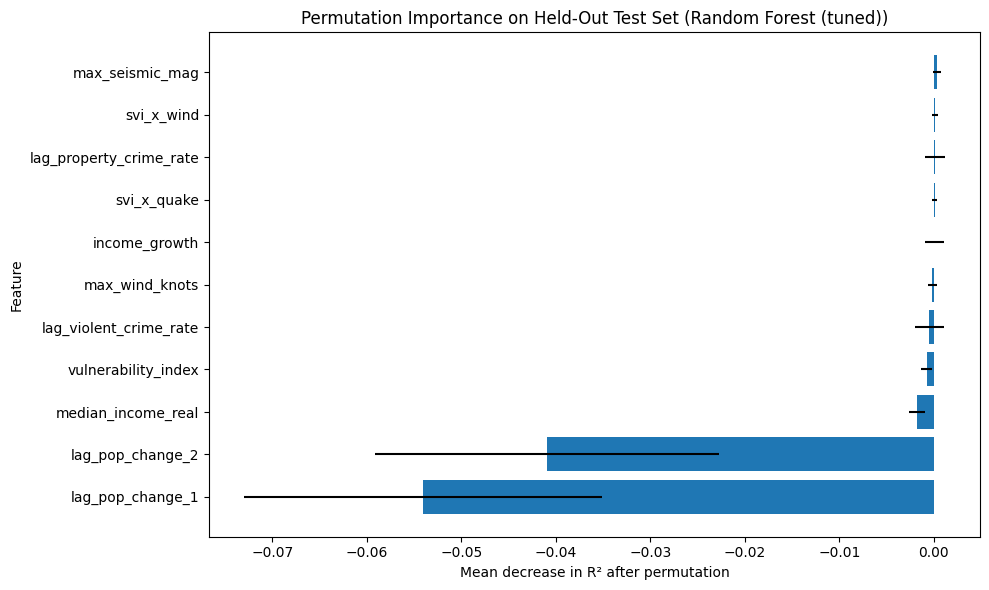

In [7]:
perm_result = permutation_importance(
    best_model,
    X_test,
    y_test,
    n_repeats=20,
    random_state=42,
    scoring='r2',
    n_jobs=-1
)

feature_importance_df = pd.DataFrame({
    'Feature': FINAL_FEATURES,
    'Importance_Mean': perm_result.importances_mean,
    'Importance_SD': perm_result.importances_std
}).sort_values(by='Importance_Mean', ascending=False)

display(feature_importance_df)

negative_importance_df = feature_importance_df[feature_importance_df['Importance_Mean'] < 0].copy()
if not negative_importance_df.empty:
    print("Features with negative permutation importance should be read cautiously as unstable or redundant signal:")
    display(negative_importance_df)

plt.figure(figsize=(10, 6))
plt.barh(
    feature_importance_df['Feature'],
    feature_importance_df['Importance_Mean'],
    xerr=feature_importance_df['Importance_SD']
)
plt.gca().invert_yaxis()
plt.title(f'Permutation Importance on Held-Out Test Set ({best_model_name})')
plt.xlabel('Mean decrease in R² after permutation')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

### Interpretation: permutation importance

The chart above ranks predictors by how much held-out performance deteriorates when each variable is
randomly permuted. Because the selected Phase 2 model may be either **Random Forest** or
**HistGradientBoosting**, the importances should be treated as **model- and sample-specific**.

If lagged population features dominate, that suggests short-run persistence still matters. If some lagged
features turn negative, that should not be read as "important in reverse"; it usually means the signal is
weak, collinear, or unstable in the test period.

## 5. Prediction Distribution: Actual vs. Predicted

This scatter plot compares the **selected best model's** predictions with observed population change in the held-out future period.


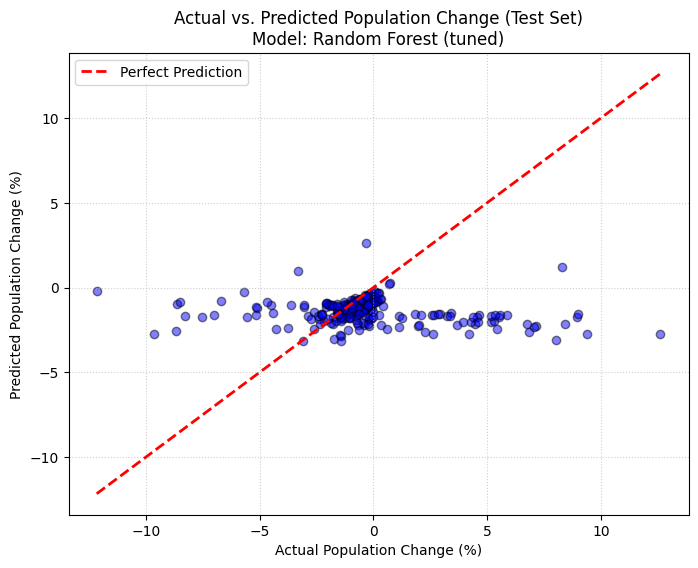

In [8]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_best_pred, alpha=0.5, color='blue', edgecolor='k')

min_val = min(y_test.min(), y_best_pred.min())
max_val = max(y_test.max(), y_best_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')

plt.title(f'Actual vs. Predicted Population Change (Test Set)\nModel: {best_model_name}')
plt.xlabel('Actual Population Change (%)')
plt.ylabel('Predicted Population Change (%)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

## Interim interpretation

At this stage, the notebook can now make cleaner comparisons because the linear baseline, naive
benchmarks, and nonlinear models are all evaluated on the **same held-out years** and on the
**same target scale**. The final conclusion appears at the end of the notebook.

## Spatial residual analysis

A simple residual map check helps detect whether the selected tuned model is systematically
over-predicting or under-predicting specific spatial contexts, such as mountainous municipalities
or coastal zones.

### Residual-map reading note

This diagnostic is descriptive rather than causal. Local clusters of over- or under-prediction can
suggest missing geography-specific covariates, but they do not by themselves prove spatial bias.

Residual summary:


,residual
count,312.000000
mean,0.900642
std,3.029428
min,-11.937508
25%,0.054348
50%,0.380034
75%,0.932396
max,15.354242


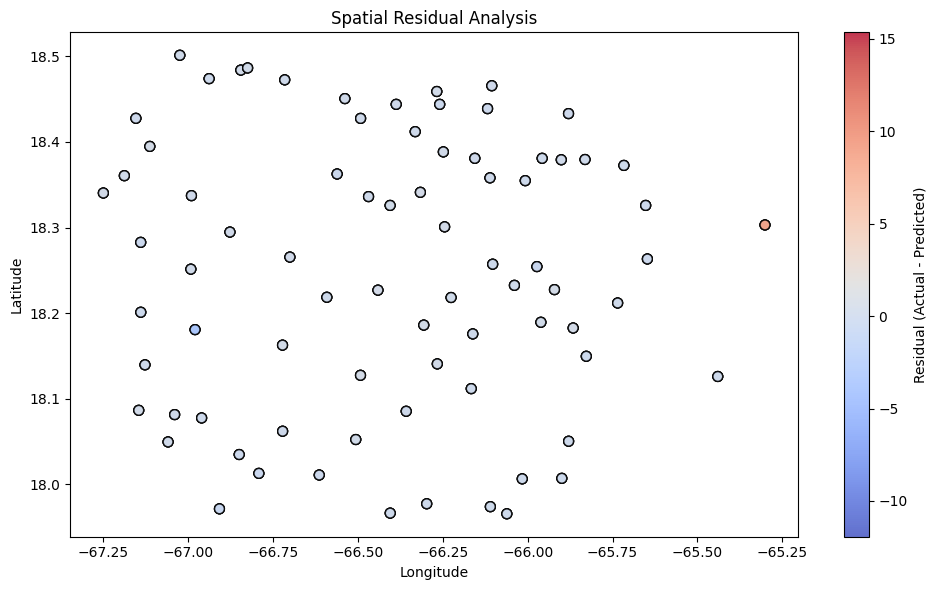

In [9]:
try:
    test_model = test_df.copy()
    target_col = 'target_pop_change'

    if "lat" in test_model.columns and "lon" in test_model.columns:
        test_model["residual"] = test_model[target_col] - y_best_pred

        print("Residual summary:")
        display(test_model[["residual"]].describe())

        valid_coords = test_model["lat"].notna() & test_model["lon"].notna()
        if valid_coords.any():
            plt.figure(figsize=(10, 6))
            scatter = plt.scatter(
                test_model.loc[valid_coords, "lon"],
                test_model.loc[valid_coords, "lat"],
                c=test_model.loc[valid_coords, "residual"],
                cmap="coolwarm",
                s=50,
                alpha=0.8,
                edgecolors="k"
            )
            plt.colorbar(scatter, label="Residual (Actual - Predicted)")
            plt.title("Spatial Residual Analysis")
            plt.xlabel("Longitude")
            plt.ylabel("Latitude")
            plt.tight_layout()
            plt.show()
        else:
            print("lat/lon columns are present, but no valid coordinates are available for plotting.")
    else:
        print("lat/lon not available in test_df for spatial residual analysis.")
except Exception as e:
    print("Spatial residual analysis could not be completed:", e)

## Experiment: pure shock impact (no persistence)

To estimate how much performance depends on short-run persistence, this experiment refits the selected
tuned model after dropping `lag_pop_change_1` and `lag_pop_change_2`. The result should be read as a
**sensitivity check**, not as proof that the remaining variables are causal drivers.

In [10]:
try:
    features_no_lags = [f for f in FINAL_FEATURES if f not in ['lag_pop_change_1', 'lag_pop_change_2']]
    X_train_no_lags = X_train[features_no_lags]
    X_test_no_lags = X_test[features_no_lags]

    model_no_lags = best_model.__class__(**best_model.get_params())
    model_no_lags.fit(X_train_no_lags, y_train)

    y_pred_no_lags = model_no_lags.predict(X_test_no_lags)
    r2_no_lags = r2_score(y_test, y_pred_no_lags)
    rmse_no_lags = np.sqrt(mean_squared_error(y_test, y_pred_no_lags))

    print("--- Model evaluation WITHOUT persistence features ---")
    print(f"Base tuned model R2 (WITH lags):    {best_model_r2:.4f}")
    print(f"Tuned model R2 (WITHOUT lags):      {r2_no_lags:.4f}")
    print(f"Tuned model RMSE (WITHOUT lags):    {rmse_no_lags:.4f}\n")

    drop = best_model_r2 - r2_no_lags
    if drop > 0:
        print(
            f"Insight: Removing demographic momentum lowers R2 by {drop:.4f}. "
            "Persistence helps in this configuration, but the magnitude should be read as modest unless the drop is large."
        )
    elif drop < 0:
        print(
            f"Insight: Removing demographic momentum improves R2 by {-drop:.4f}. "
            "That would suggest the lag terms are not contributing stable held-out signal in this specification."
        )
    else:
        print("Insight: Removing demographic momentum produced no measurable change in held-out R2.")

except Exception as e:
    print("Could not complete the no-lags experiment:", e)

--- Model evaluation WITHOUT persistence features ---
Base tuned model R2 (WITH lags):    -0.2461
Tuned model R2 (WITHOUT lags):      -0.2621
Tuned model RMSE (WITHOUT lags):    3.1759

Insight: Removing demographic momentum lowers R2 by 0.0159. Persistence helps in this configuration, but the magnitude should be read as modest unless the drop is large.


## Phase 2 Conclusion: Nonlinear Modeling, Persistence, and Forecasting Limits

Phase 2 extends the reduced-feature linear benchmark by introducing nonlinear ensemble models,
lagged demographic dynamics, and a broader set of socioeconomic and disaster-related predictors.
The objective was to test whether a richer feature space and more flexible modeling approaches
could improve the ability to forecast municipal population change across Puerto Rico.

### Methodological improvements
Several methodological upgrades were implemented relative to Phase 1:

- The feature space was expanded to include **lagged population change**, economic indicators,
  disaster exposure variables, and a **composite social vulnerability index (SVI)** derived from
  standardized socioeconomic measures.
- Two nonlinear ensemble models—**Random Forest** and **Histogram Gradient Boosting**—were
  introduced to capture potential nonlinear relationships and interaction effects.
- Model evaluation now uses **expanding-window, year-block cross-validation**, ensuring that
  models are always trained on past years and validated on future observations, which better
  reflects the forecasting setting.

### What the results show
Across model specifications, the tuned Random Forest achieved the strongest performance on the
held-out test period. Although the best model improved relative to simpler benchmarks—including
the reduced-feature linear model and naive forecasting baselines—the overall **test-set R²
remained negative**.

This result suggests that the expanded feature set and nonlinear models capture some additional
structure in the data, but the underlying forecasting problem remains difficult. Municipal
population change appears to be influenced by factors that are only partially observed in the
current dataset, and the signal available in the predictors remains limited.

### Diagnostic insights
Additional analyses provided insight into model behavior:

- **Permutation importance** indicates that economic conditions, vulnerability measures, and
  certain disaster-related features contribute to predictive performance, though importance
  values remain relatively modest and somewhat unstable.
- Removing lagged population features produced only a **small decline in performance**, suggesting
  that persistence helps but is not the dominant driver of predictions in the current model.
- Residual diagnostics show that prediction errors remain large for several municipalities,
  reinforcing the difficulty of forecasting local demographic change with the current predictors.

### Implications for Phase 3
Phase 2 demonstrates that nonlinear modeling and expanded feature engineering can provide
incremental improvements over simpler baselines, but the persistence of negative out-of-sample
R² indicates that further refinement is necessary.

Phase 3 will therefore focus on strengthening the predictive framework by exploring:

1. **Richer economic and migration covariates**
2. **Alternative lag structures and persistence benchmarks**
3. **Geography-aware effects or regional clustering**
4. **Model architectures that better capture temporal dependence while remaining interpretable**

In this sense, Phase 2 provides an important diagnostic step: it clarifies which modeling
extensions offer modest gains, which signals remain weak, and which directions are most
promising for improving the forecasting framework in the next phase.

In [11]:
# --- Phase 2 Export Artifacts for Phase 4 ---
from pathlib import Path
import json
import pandas as pd

analysis_dir = Path('.')

# Save the actual Phase 2 modeling dataset used after all feature engineering.
# IMPORTANT: vulnerability_index is created on train_df/test_df AFTER df_model exists,
# so we export the concatenated train/test frames rather than the pre-PCA df_model.
processed_path = Path('../data/processed_puerto_rico_data.csv')

processed_df = None
if 'train_df' in globals() and 'test_df' in globals():
    processed_df = pd.concat([train_df.copy(), test_df.copy()], ignore_index=True)
elif 'df_model' in globals():
    processed_df = df_model.copy()
elif 'df_clean' in globals():
    processed_df = df_clean.copy()

if processed_df is None:
    print("Warning: Could not identify a processed Phase 2 modeling dataset to export.")
else:
    if 'split' not in processed_df.columns:
        if 'TRAIN_END_YEAR' in globals() and 'TEST_START_YEAR' in globals() and 'year' in processed_df.columns:
            processed_df['split'] = processed_df['year'].apply(
                lambda y: 'train' if y <= TRAIN_END_YEAR else ('test' if y >= TEST_START_YEAR else 'unused')
            )

    processed_df.to_csv(processed_path, index=False)
    print(f"Saved processed dataset to: {processed_path}")
    print(f"Processed dataset shape: {processed_df.shape}")

    required_phase4_cols = [
        'vulnerability_index',
        'median_income_real',
        'max_wind_knots',
        'max_seismic_mag',
        'lag_violent_crime_rate',
        'lag_property_crime_rate',
        'lag_pop_change_1',
        'lag_pop_change_2',
        'income_growth',
        'target_pop_change',
        'year'
    ]
    missing_phase4_cols = [c for c in required_phase4_cols if c not in processed_df.columns]
    if missing_phase4_cols:
        print("Warning: Exported processed dataset is still missing columns needed by Phase 4:", missing_phase4_cols)
    else:
        print("Verified: exported processed dataset includes all required Phase 4 columns.")

phase2_summary = {}

try:
    phase2_summary.update({
        'best_model_name': best_model_name if 'best_model_name' in globals() else None,
        'best_model_type': best_model.__class__.__name__ if 'best_model' in globals() else None,
        'best_model_params': best_model.get_params() if 'best_model' in globals() else None,
        'final_features': FINAL_FEATURES if 'FINAL_FEATURES' in globals() else None,
        'baseline_features': BASELINE_FEATURES if 'BASELINE_FEATURES' in globals() else None,
        'target_col': 'target_pop_change',
        'train_years': sorted(train_df['year'].unique().tolist()) if 'train_df' in globals() else None,
        'test_years': sorted(test_df['year'].unique().tolist()) if 'test_df' in globals() else None,
    })
except Exception as e:
    print('Warning building summary metadata:', e)

metric_name_map = {
    'best_model_r2': 'best_model_r2',
    'best_model_mae': 'best_model_mae',
    'best_model_rmse': 'best_model_rmse',
    'linear_baseline_r2': 'linear_baseline_r2',
    'linear_baseline_mae': 'linear_baseline_mae',
    'linear_baseline_rmse': 'linear_baseline_rmse',
    'naive_zero_r2': 'naive_zero_r2',
    'naive_zero_mae': 'naive_zero_mae',
    'naive_zero_rmse': 'naive_zero_rmse',
    'naive_persistence_r2': 'naive_persistence_r2',
    'naive_persistence_mae': 'naive_persistence_mae',
    'naive_persistence_rmse': 'naive_persistence_rmse',
    'r2_no_lags': 'r2_no_lags',
    'rmse_no_lags': 'rmse_no_lags'
}
for out_key, var_name in metric_name_map.items():
    if var_name in globals():
        try:
            phase2_summary[out_key] = float(globals()[var_name])
        except Exception:
            phase2_summary[out_key] = None

if 'comparison_df' in globals():
    try:
        phase2_summary['comparison_table'] = comparison_df.to_dict(orient='records')
    except Exception as e:
        print('Warning saving comparison table:', e)

summary_path = analysis_dir / 'phase2_model_selection_summary.json'
with open(summary_path, 'w') as f:
    json.dump(phase2_summary, f, indent=4)

print(f'Saved Phase 2 model summary to: {summary_path}')



Saved processed dataset to: ../data/processed_puerto_rico_data.csv
Processed dataset shape: (936, 67)
Verified: exported processed dataset includes all required Phase 4 columns.
Saved Phase 2 model summary to: phase2_model_selection_summary.json
